Premiers essais du projet !

In [4]:
import tensorflow as tf
#import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
dataset_df = pd.read_csv('train.csv')
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (8693, 14)


In [6]:
dataset_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [7]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


<Axes: xlabel='Transported'>

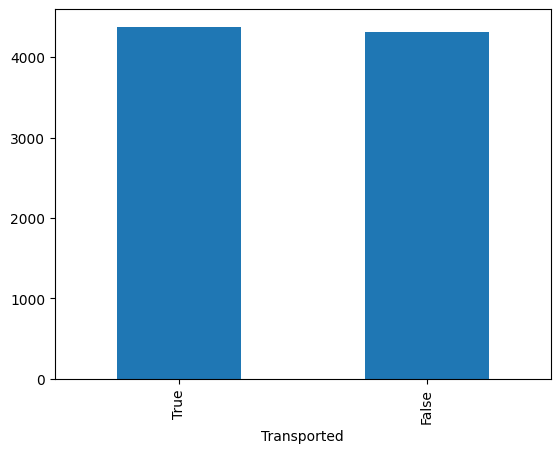

In [8]:
plot_df = dataset_df.Transported.value_counts()
plot_df.plot(kind="bar")

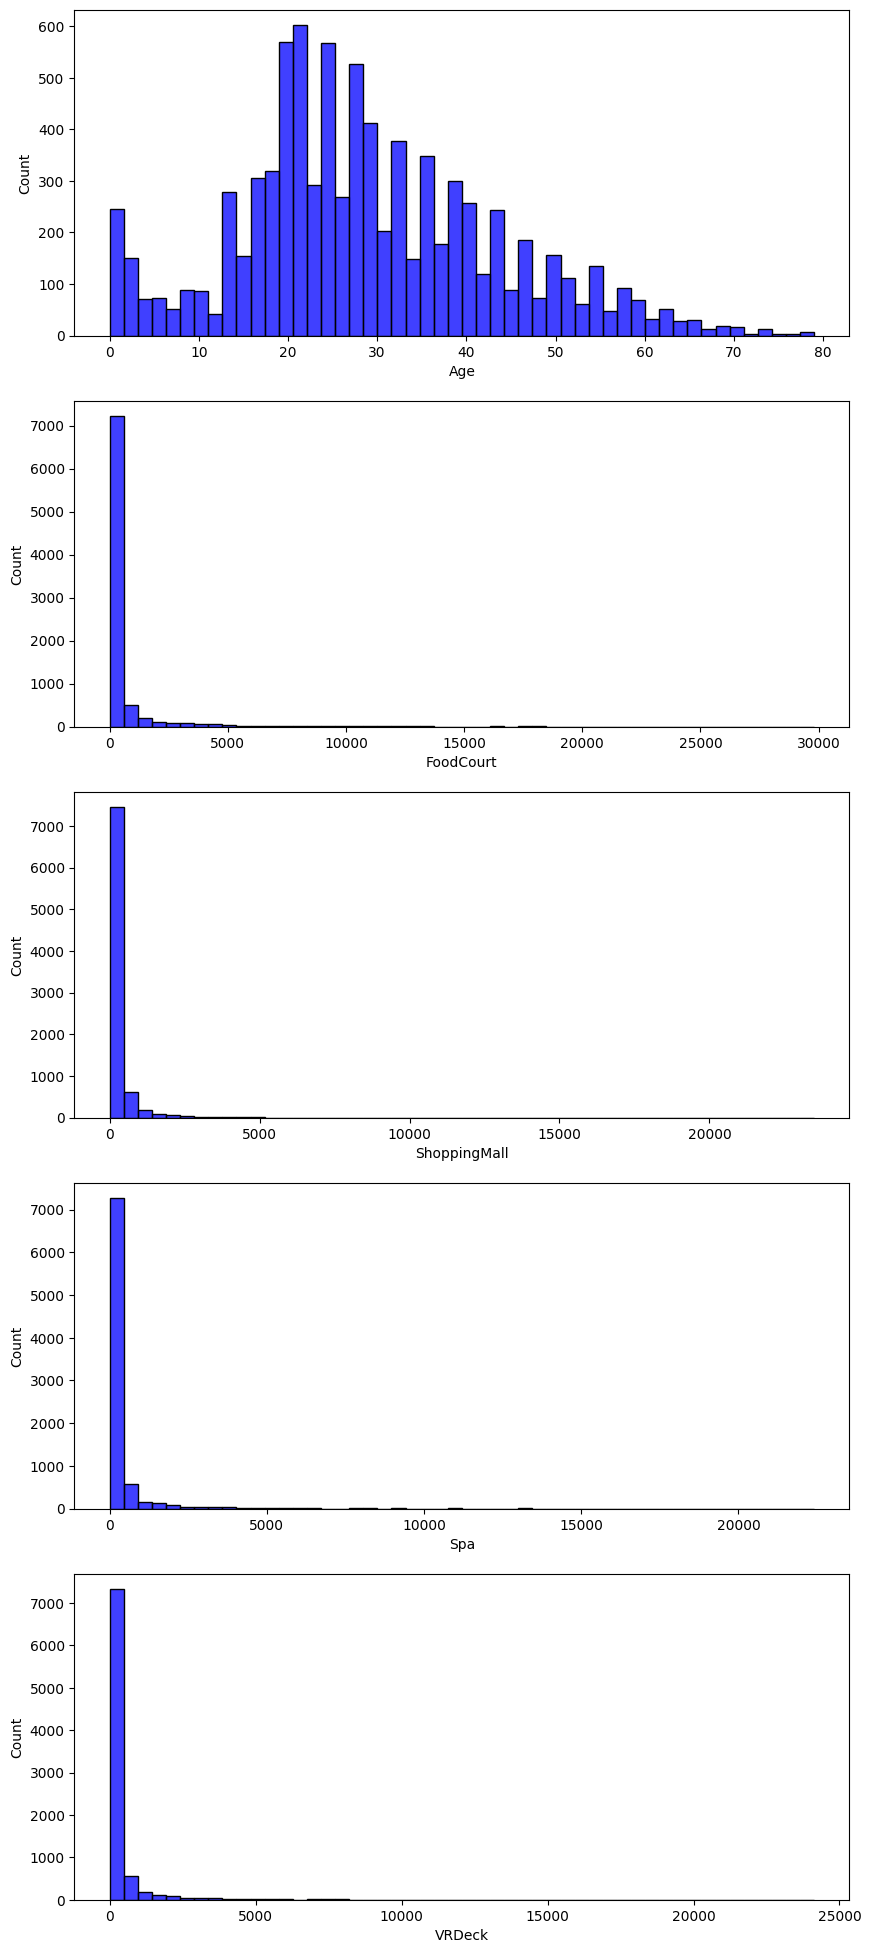

In [9]:
fig, ax = plt.subplots(5,1,  figsize=(10, 10))
plt.subplots_adjust(top = 2)

sns.histplot(dataset_df['Age'], color='b', bins=50, ax=ax[0]);
sns.histplot(dataset_df['FoodCourt'], color='b', bins=50, ax=ax[1]);
sns.histplot(dataset_df['ShoppingMall'], color='b', bins=50, ax=ax[2]);
sns.histplot(dataset_df['Spa'], color='b', bins=50, ax=ax[3]);
sns.histplot(dataset_df['VRDeck'], color='b', bins=50, ax=ax[4]);

In [10]:
valeurs_uniques = dataset_df['HomePlanet'].unique()
print(valeurs_uniques)


['Europa' 'Earth' 'Mars' nan]


<h2>Modification de la colonne Cabin</h2>

In [31]:
dataset_df[['Deck', 'Num', 'Side']] = dataset_df['Cabin'].str.split('/', expand=True)

#traitement de la colone Side
side_mapping={"P":1,"S":-1}
dataset_df['Side'] = dataset_df['Side'].map(side_mapping)

#traitement de la colone Deck
deck_mapping={"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
dataset_df['Deck'] = dataset_df['Deck'].map(deck_mapping)


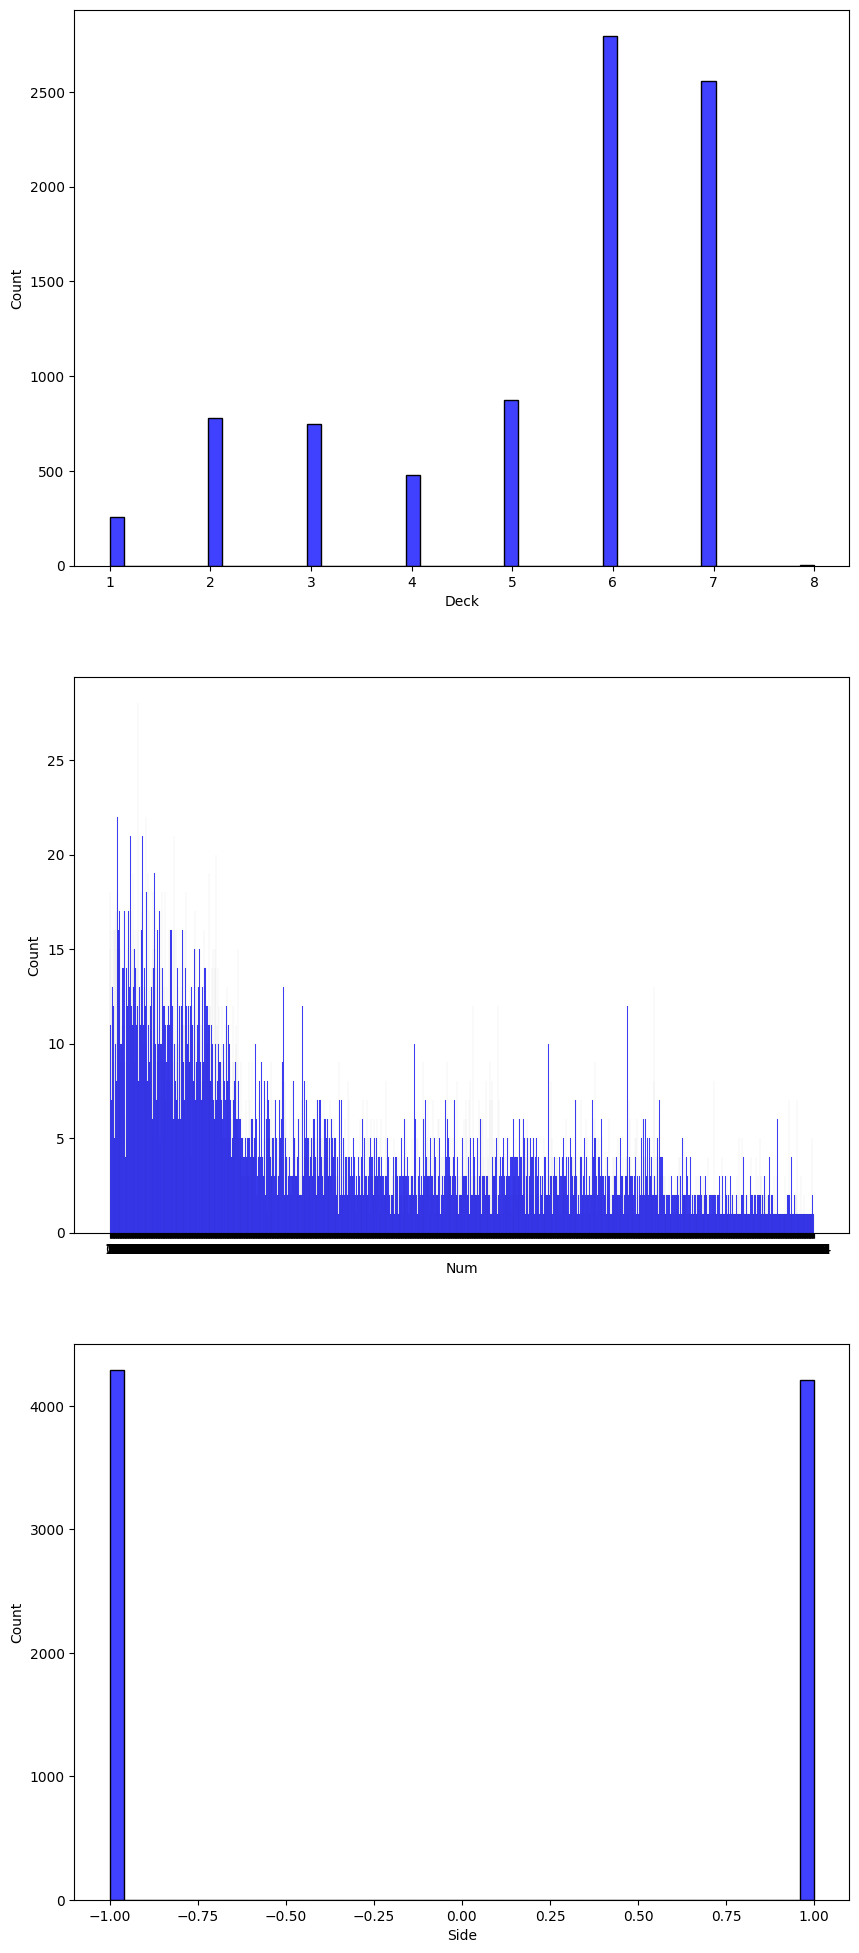

In [12]:
fig, ax = plt.subplots(3,1,  figsize=(10, 10))
plt.subplots_adjust(top = 2)
sns.histplot(dataset_df['Deck'], color='b', bins=50, ax=ax[0]);
sns.histplot(dataset_df['Num'], color='b', bins=50, ax=ax[1]);
sns.histplot(dataset_df['Side'], color='b', bins=50, ax=ax[2]);

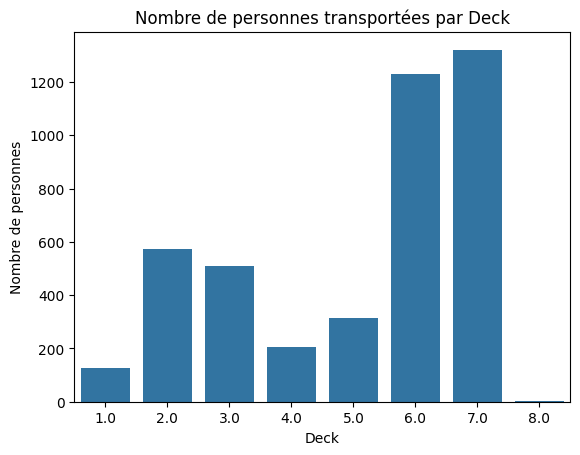

In [13]:
transported_df = dataset_df[dataset_df['Transported'] == True]
sns.countplot(x='Deck', data=transported_df)
plt.title('Nombre de personnes transportées par Deck')
plt.xlabel('Deck')
plt.ylabel('Nombre de personnes')
plt.show()

<h3>Dans le prochain graphe, on a la proportion de personne transporté au sein d'un meme deck, cela permet d'identifier la propbabilité statistique d'être transporté pour chaque deck.</h3>

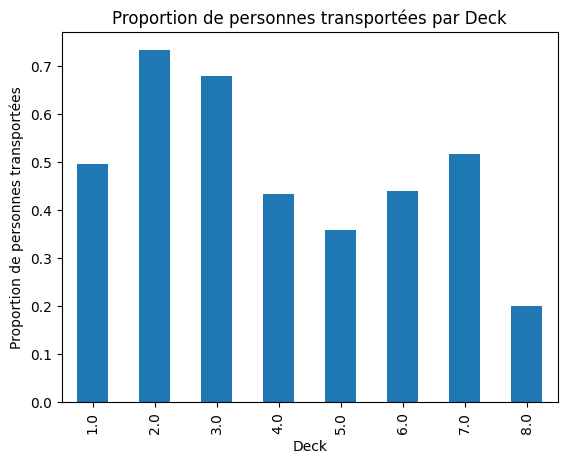

In [14]:
proportions = dataset_df.groupby('Deck')['Transported'].mean()
proportions.plot(kind='bar')
plt.title('Proportion de personnes transportées par Deck')
plt.xlabel('Deck')
plt.ylabel('Proportion de personnes transportées')
plt.show()

<h3>Dans le graphe suivant, on affiche la proportion de personnes transportées dans chaque deck par rapport au nombre total de personne transportées. Cela nous informe d'où viennent la majorité des passagers transportés mais ne nous informe pas sur la proportion de transpotées au sein d'un meme deck.</h3>

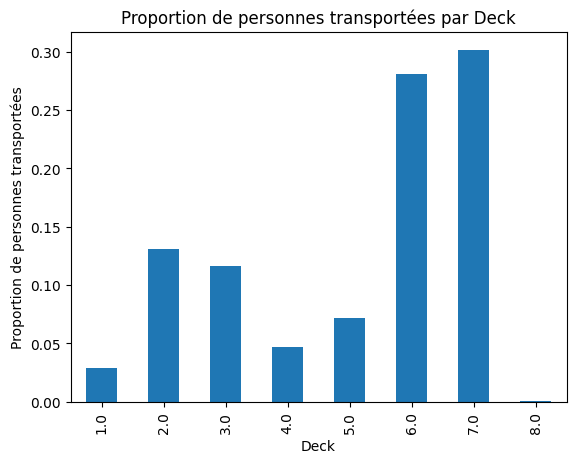

In [15]:
total_transported = dataset_df['Transported'].sum()
proportions = dataset_df[dataset_df['Transported'] == True].groupby('Deck').size() / total_transported
proportions.plot(kind='bar')
plt.title('Proportion de personnes transportées par Deck')
plt.xlabel('Deck')
plt.ylabel('Proportion de personnes transportées')
plt.show()

<h2>Traitement de PassengerId</h2>

In [25]:
dataset_df[['group','num_in_the_group']] = dataset_df['PassengerId'].str.split('_', expand=True)
dataset_df=dataset_df.drop(columns=['num_in_the_groupe'])
dataset_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,group,num_in_the_group
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,2.0,0,1.0,0001,01
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,6.0,0,-1.0,0002,01
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1.0,0,-1.0,0003,01
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,1.0,0,-1.0,0003,02
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,6.0,1,-1.0,0004,01


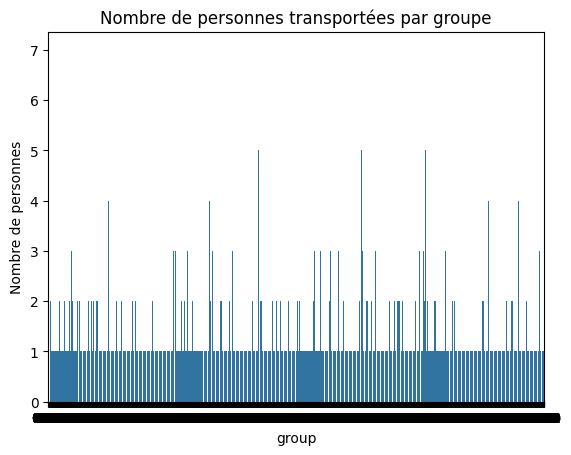

In [29]:
transported_df = dataset_df[dataset_df['Transported'] == True]
sns.countplot(x='group', data=transported_df)
plt.title('Nombre de personnes transportées par groupe')
plt.xlabel('groupe')
plt.ylabel('Nombre de personnes')
plt.show()

<h3>Aucune tendance ne semble se dégager concernant le numéro du groupe de passagers. On poura cependant par la suite essayer de trouver un lien entre le groupe et d'autre variable telle que le nom de famille ou le numéro de cabine, ou bien encore le deck.</h3>

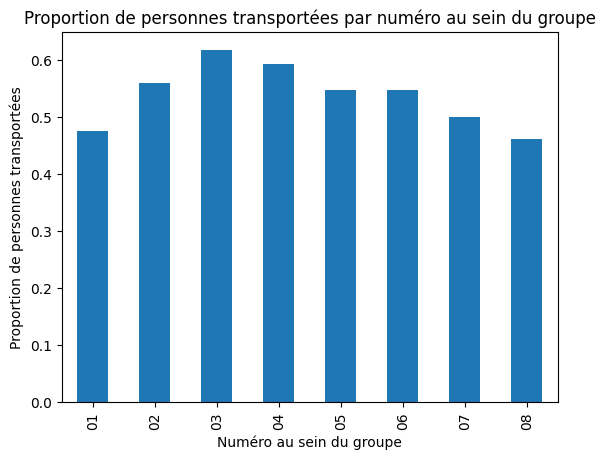

In [30]:
proportions = dataset_df.groupby('num_in_the_group')['Transported'].mean()
proportions.plot(kind='bar')
plt.title('Proportion de personnes transportées par numéro au sein du groupe')
plt.xlabel('Numéro au sein du groupe')
plt.ylabel('Proportion de personnes transportées')
plt.show()

<h3>Le numéro au sein du groupe semble avoir un impact sur la probabilité d'être transporté.</h3>

<h1><i>Fonction de traitement des données</i></h1>

In [ ]:
def traitement_dataset(dataset_df):
    dataset_df[['Deck', 'Num', 'Side']] = dataset_df['Cabin'].str.split('/', expand=True)
    side_mapping={"P":1,"S":-1}
    dataset_df['Side'] = dataset_df['Side'].map(side_mapping)
    deck_mapping={"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7}
    dataset_df['Deck'] = dataset_df['Deck'].map(deck_mapping)
    dataset_df[['group','num_in_the_group']] = dataset_df['PassengerId'].str.split('_', expand=True)
    